# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [18]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [20]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print(df.isna().mean(axis = 0))

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ["alive", 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
df = df.drop(columns=leaky)

print("Các cột còn lại:", list(df.columns))

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

*(viết tại đây...)*
Có 2 lý do chính:
- Cột 'alive' và cột 'survived' có ý nghĩa giống hệt nhau, chỉ khác nhau ở giá trị (alive là yes/no, survived là 1/0) -> 2 cột này tương quan dương hoàn hảo. Mô hình sẽ phát hiện ra quy luật rất dễ là nếu alive == yes thì chắc chặn survived = 1 và ngược lại. Mô hình sẽ đánh trọng số rất cao cho cột alive trong khi các đặc trưng quan trọng khác như (age, sex, class) thì bị đánh trọng số thấp.
- Trong thực tế khi đi dự đoán cho một khách hàng mới, ta sẽ không biết trước cột 'alive', vì vậy hiệu quả của mô hình sẽ rất tệ.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [25]:
# TODO 2: shape, info, describe
print("Shape của dataset:", df.shape)
print("Biến mục tiêu: survived")
print("----info của dataset----")
print(df.info())


Shape của dataset: (891, 8)
Biến mục tiêu: survived
----info của dataset----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
None


In [30]:
print(df.describe()) #Cho dữ liệu kiểu số

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [31]:
print(df.describe(include="object"))

         sex embarked
count    891      889
unique     2        3
top     male        S
freq     577      644


**Trả lời 2 (biến số vs biến phân loại):**

*(viết tại đây...)*
- biến số là cột age, sibsp, parch, fare
- biến phân loại là survived, pclass, sex, embarked

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [ ]:
# TODO 3: bảng missing (count + %)
missing_count = df.isna().sum()
missing_percentage = df.isna().mean()*100
pd.DataFrame({
    "Feature": list(df.columns), 
    "Count": missing_count, 
    "Percentage": missing_percentage}).reset_index(drop = True)

,Feature,Count,Percentage
0,survived,0,0.000000
1,pclass,0,0.000000
2,sex,0,0.000000
3,age,177,19.865320
4,sibsp,0,0.000000
5,parch,0,0.000000
6,fare,0,0.000000
7,embarked,2,0.224467


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| age | 19.86% | Nên điền vào các giá trị thiếu bằng mean hoặc median (tùy thuộc vào có nhiều outliers hay không) | Chỉ thiếu 20% dữ liệu, không nên bỏ cột age hoặc bỏ các mẫu có giá trị missing vì làm hao hụt lượng dữ liệu trong khi dataset gốc đã có rất ít khách hàng rồi và cột age cũng rất có ý nghĩa cho mô hình dư đoán tỷ lệ sống |
| embarked | 0.22% | Có thể điền mode vào| Tỷ lệ thiếu rất nhỏ, dù xóa vài mẫu thiếu hoặc điền mode cũng không ảnh hưởng quá nhiều|

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [49]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    # trả về số lượng outlier theo IQR
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    return ((s < Q1 - 1.5*IQR) | (s >  Q3 + 1.5*IQR)).sum()

def dem_outlier_zscore(s, nguong=3.0):
    # trả về số lượng outlier theo Z-score
    clean_s = s.dropna()
    Z_score = (clean_s - clean_s.mean()) / clean_s.std()
    return (np.abs(Z_score) > 3).sum()

for col in ["age", "fare"]:
    print(f"outliers theo iqr của {col} là: {dem_outlier_iqr(df[col])}, theo zscore là {dem_outlier_zscore(df[col])}")

outliers theo iqr của age là: 11, theo zscore là 2
outliers theo iqr của fare là: 116, theo zscore là 20


**Trả lời 4 (quyết định với outlier của `fare`):**

*(viết tại đây...)*
Nên giữ lại các outliers của `fare`, việc giá cao là do pclass thường bằng 1 hoặc 2, chứng tỏ giá mắc là vì đây là khoang hạng thương gia, không phải vì do bất thường hoặc lỗi.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

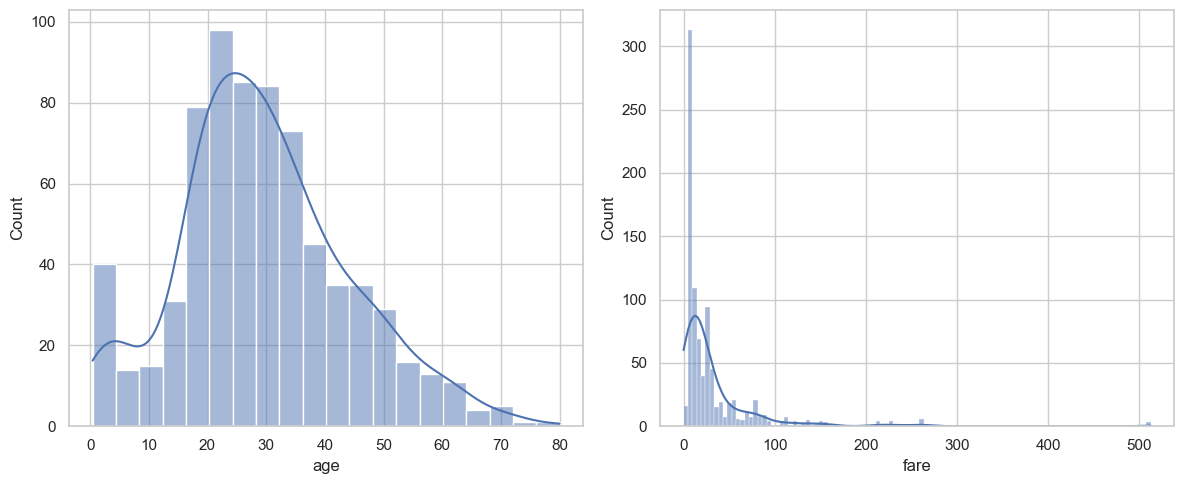

In [60]:
# TODO 5a: Histogram age & fare
figure, axes = plt.subplots(1, 2, figsize = (12, 5))
sns.histplot(data = df, x = 'age', ax = axes[0], kde = True)
sns.histplot(data = df, x = 'fare', ax = axes[1], kde = True)
plt.tight_layout()
plt.show()

Nhật xét: 
- `age` có xu hướng tuân theo phân phối chuẩn, hơi lệch phải
- `fare` lệch phải rất nhiều, đa số khách hàng mua vé tàu phân khúc giá rẻ (dưới 100)

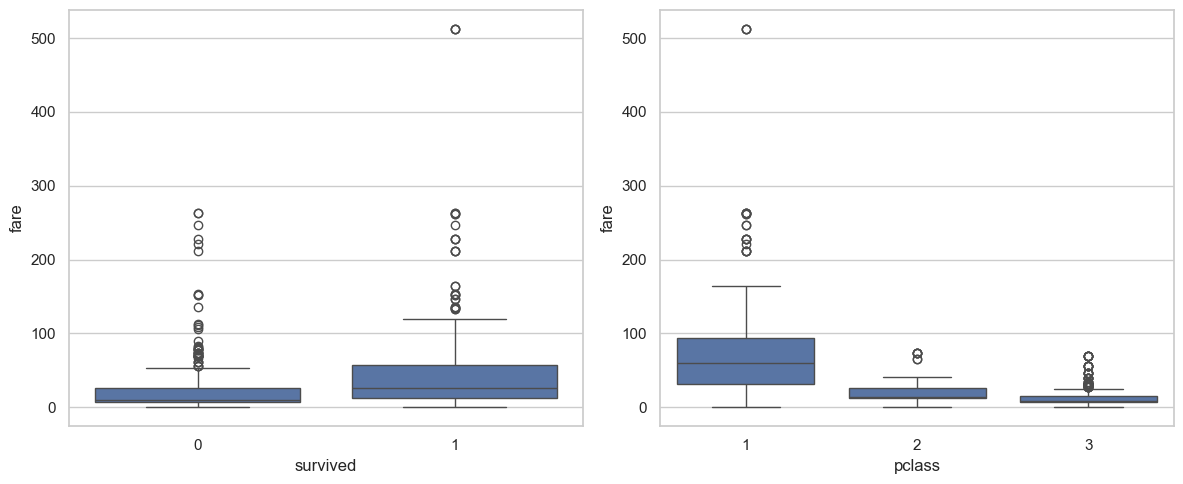

In [63]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
figure, axes = plt.subplots(1, 2, figsize = (12, 5))
sns.boxplot(data = df, x = 'survived', y = 'fare', ax = axes[0])
sns.boxplot(data = df, x = 'pclass', y = 'fare', ax = axes[1])
plt.tight_layout()
plt.show()

In [ ]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='sex', y='survived', ax=axes[0], errorbar=None, palette='muted')
axes[0].set_title('Tỷ lệ sống sót theo Giới tính (Sex)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Giới tính (Sex)', fontsize=11)
axes[0].set_ylabel('Tỷ lệ sống sót', fontsize=11)

sns.barplot(data=df, x='pclass', y='survived', ax=axes[1], errorbar=None, palette='muted')
axes[1].set_title('Tỷ lệ sống sót theo Hạng vé (Pclass)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Hạng vé (Pclass)', fontsize=11)
axes[1].set_ylabel('Tỷ lệ sống sót', fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(8, 6))
corr_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng số', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- **Histogram:** Phân phối độ tuổi (`age`) tương đối chuẩn (gần hình chuông) nhưng hơi lệch phải nhẹ, tập trung phần lớn ở thanh niên từ 20 đến 40 tuổi. Trong khi đó, phân phối giá vé (`fare`) bị lệch phải cực đoan (skewed), với đại đa số vé nằm ở mức thấp (dưới 50 USD) và chỉ một số rất ít hành khách mua vé hạng VIP có giá cực kỳ cao (lên tới hơn 500 USD).
- **Boxplot:** Biểu đồ cho thấy nhóm hành khách sống sót (`survived` = 1) có trung vị giá vé (`fare`) cao hơn hẳn nhóm tử vong. Hạng vé thứ nhất (`pclass` = 1) có mức giá vé trải rộng nhất và chứa hầu hết các ngoại lai (outliers) có giá vé đắt đỏ, trong khi hạng 2 và hạng 3 có phân phối giá vé thấp và tập trung.
- **Bar survival:** Cho thấy sự chênh lệch rõ rệt về cơ hội sống sót. Nữ giới có tỷ lệ sống sót vượt trội so với nam giới (khoảng 74% so với 19%). Đồng thời, hành khách mua vé hạng 1 có cơ hội sống sót cao nhất (~63%), tiếp theo là hạng 2 (~47%) và thấp nhất là hạng 3 (~24%). Điều này cho thấy yếu tố giới tính và địa vị xã hội (hạng vé) ảnh hưởng cực kỳ lớn đến khả năng cứu hộ.
- **Heatmap:** Cặp đặc trưng có tương quan nghịch mạnh nhất là hạng vé `pclass` và giá vé `fare` (-0.55), nghĩa là số hiệu hạng vé càng thấp (hạng 1) thì giá vé càng cao. Đối với khả năng sống sót (`survived`), hạng vé `pclass` có mối tương quan nghịch mạnh nhất (-0.34 - hạng vé càng thấp cơ hội sống càng giảm) và `fare` tương quan thuận mạnh nhất (0.26 - giá vé càng cao cơ hội sống càng tăng). Các đặc trưng gia đình như `sibsp` và `parch` có tương quan thuận ở mức vừa phải (0.41).

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [77]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns = 'survived')
y = df['survived']
#stratify giúp giữ nguyên tỉ lệ các lớp của tập dữ liệu gốc sau khi chia tập thành 3 tập train/test/split
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size = 0.15, random_state = 42, stratify = y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size = 15/85, random_state = 42, stratify = y_tmp)

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)
# in tỷ lệ survived từng tập
print(f"Tỷ lệ survived của Train/Val/Test:, {y_train.mean():.4f} {y_val.mean():.4f} {y_test.mean():.4f}")

Train/Val/Test: (623, 7) (134, 7) (134, 7)
Tỷ lệ survived của Train/Val/Test:, 0.3836 0.3881 0.3806


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [82]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("onehot",  OneHotEncoder()),
])


preprocess = ColumnTransformer([
    ("num_road", pipe_so,  num_cols),
    ("cat_road", pipe_cat, cat_cols),
    ("ord_road", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
# ... transform cho val, test
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)
print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(623, 10) ['num_road__age', 'num_road__sibsp', 'num_road__parch', 'num_road__fare', 'cat_road__sex_female', 'cat_road__sex_male', 'cat_road__embarked_C', 'cat_road__embarked_Q', 'cat_road__embarked_S', 'ord_road__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Khi chuẩn bị dữ liệu cho mô hình, các phép tiền xử lý (như điền giá trị thiếu bằng `median` hay chuẩn hóa bằng `RobustScaler`) đòi hỏi việc học (học giá trị trung vị, phân phối, độ lệch) từ dữ liệu thông qua lệnh `.fit()`.

Nếu chúng ta gọi `.fit()` trên **toàn bộ dữ liệu** trước khi chia tập (hoặc gộp cả tập test/val vào để fit):
1. Các tham số thống kê (như giá trị trung vị của cột `age`, hoặc phân phối giá vé `fare`) sẽ bị ảnh hưởng bởi các giá trị nằm trong tập validation và test.
2. Điều này làm cho thông tin từ tương lai (tập test/val) bị "rò rỉ" vào quá trình huấn luyện mô hình. Hiện tượng này gọi là **Data Leakage (Rò rỉ dữ liệu)**, khiến mô hình đạt điểm số đánh giá rất cao trên giấy tờ nhưng khi chạy thực tế sẽ rất tệ.

Do đó, việc chỉ `.fit()` trên `X_train` giúp đảm bảo bộ tiền xử lý chỉ học quy luật hoàn toàn từ tập huấn luyện. Tập validation và test sau đó sẽ chỉ gọi `.transform()` (áp dụng các giá trị trung vị, min/max đã học từ tập train lên tập test) để đảm bảo tính khách quan tuyệt đối, giống như khi mô hình gặp dữ liệu khách hàng hoàn toàn mới trong thực tế.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [ ]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
survived_counts = df['survived'].value_counts()
survived_pct = df['survived'].value_counts(normalize=True) * 100
print("Số lượng hành khách tử vong (0) và sống sót (1):")
print(survived_counts)
print("\nTỷ lệ phần trăm (%):")
print(survived_pct)

**Trả lời 8:**

1. Biến mục tiêu `survived` có sự mất cân bằng ở mức độ nhẹ đến vừa phải. Cụ thể, số ca tử vong (nhãn 0) chiếm khoảng 61.6% (549 mẫu) và số ca sống sót (nhãn 1) chiếm khoảng 38.4% (342 mẫu).
2. Chỉ số **Accuracy** (độ chính xác tổng thể) sẽ bị đánh lừa khi tập dữ liệu bị mất cân bằng nghiêm trọng. Ví dụ, nếu lớp đa số chiếm tới 95%, một mô hình đơn giản chỉ cần dự báo mọi mẫu đều thuộc lớp đa số vẫn đạt Accuracy 95% mà không cần học bất kỳ quy luật nào, đồng thời bỏ sót hoàn toàn 5% lớp thiểu số (lớp quan trọng). Với Titanic, sự mất cân bằng ở mức 61.6% vs 38.4% tuy không quá lớn nhưng việc chỉ nhìn vào Accuracy vẫn có thể che giấu việc mô hình dự đoán sai nhiều ở lớp sống sót.
3. Với bài toán Titanic, ta nên ưu tiên sử dụng chỉ số **F1-score** (hoặc đồng thời theo dõi sát **Precision** và **Recall** trên nhãn 1) thay vì chỉ nhìn vào Accuracy.
   - **Precision** giúp kiểm soát sai số loại 1 (tránh dự đoán nhầm một người sống sót trong khi họ tử vong).
   - **Recall** giúp kiểm soát sai số loại 2 (tránh bỏ sót những hành khách thực tế đã sống sót).
   Vì F1-score là trung bình điều hòa của Precision và Recall, nó giúp phản ánh một cách trung thực năng lực dự đoán của mô hình đối với lớp thiểu số (lớp sống sót).

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. **Đặc trưng tương quan mạnh nhất với khả năng sống sót:** Hạng vé (`pclass` có tương quan nghịch -0.34) và Giá vé (`fare` có tương quan thuận 0.26) là các đặc trưng số tương quan mạnh nhất với khả năng sống sót. Điều này cho thấy những người có hạng vé tốt hơn (hạng 1) và trả tiền nhiều hơn thì có cơ hội sống sót cao hơn rõ rệt. Về mặt phân loại, giới tính nữ (`sex` = female) cũng là yếu tố tương quan cực kỳ mạnh mẽ với tỷ lệ sống sót (~74% so với ~19% ở nam).
2. **Cột thiếu dữ liệu nhiều nhất và cách xử lý:** Cột thiếu dữ liệu nhiều nhất giữ lại trong mô hình là `age` (thiếu 19.86% - 177 dòng). Chúng ta xử lý bằng cách điền khuyết bằng giá trị trung vị (`median`) trong Pipeline tiền xử lý của tập huấn luyện. Giá trị trung vị bền vững hơn trung bình (`mean`) do độ tuổi phân bố hơi lệch phải nhẹ và để tránh ảnh hưởng bởi giá trị ngoại lai. Cột `embarked` thiếu rất ít (0.22% - 2 dòng) được xử lý bằng cách điền yếu vị (`most_frequent` / `mode`). Cột `deck` bị loại bỏ từ Task 1 do thiếu quá nhiều (~77.2%).
3. **Mất cân bằng biến mục tiêu và ảnh hưởng chọn metric:** Biến mục tiêu `survived` có mất cân bằng nhẹ (61.6% tử vong vs 38.4% sống sót). Sự mất cân bằng này làm giảm độ tin cậy của chỉ số Accuracy đơn thuần, do đó chúng ta cần ưu tiên sử dụng F1-score để đánh giá hiệu năng mô hình một cách khách quan trên cả hai lớp.
4. **Các đặc trưng cần Scaling và Encoding:**
   - Các đặc trưng số liên tục như `age` và đặc biệt là `fare` (do lệch phải cực đoan và có nhiều outlier) cần được **scaling** bằng `RobustScaler` (sử dụng Median và IQR) để tránh các outlier làm méo mó các thang đo.
   - Các đặc trưng phân loại dạng chữ như `sex` và `embarked` cần được **encoding** bằng `OneHotEncoder` để chuyển đổi sang các biến giả (dummy variables) dạng số nhị phân 0/1 mà mô hình học máy có thể hiểu được.
5. **Một điều bất ngờ/thú vị trong dữ liệu:** Đó là sự ưu tiên cứu hộ gần như tuyệt đối dành cho Phụ nữ (`sex` = female) và những người có địa vị cao (Hạng vé `pclass` = 1). Một người phụ nữ ở hạng vé thứ 3 vẫn có cơ hội sống sót cao hơn nhiều so với một người đàn ông ở hạng vé thứ 1. Điều này chứng minh quy luật nhân đạo lịch sử "phụ nữ và trẻ em được ưu tiên" đã thực sự được thực hiện nghiêm túc trong vụ đắm tàu Titanic lịch sử.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [ ]:
# (tùy chọn) code cho phần Bonus
...

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
